In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

exo = pd.read_csv("exoplanet_data.csv", comment="#")
exo.shape

(564, 92)

In [6]:
# 594 rows (instances of stars), 92 columns (different variables of the stars)
print(exo.columns)

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [ ]:
# don't know what a lot of these mean. probably makes more sense on the webpage itself,
# where the info isn't a shorthand. in this case, five that I'll chose are:
# pl_bmassprov
# sy_kmagerr1
# sy_gaiamag (magnitude? gaia as in the god?)
# st_tefferr1
# ttv_flag

In [7]:
# i dont actually know how to find the names of the columns, so I googled it and it didn't
# tell me but it gave me the answers... so
"""
Planet Name
 - pl_name
 - name of planet
Host Name
 - hostname
 - name of the host star
Discovery Method
 - discoverymethod
 - how it was discovered
Spectral Type
 - st_spectype
 - the spectral type of the star
Equilibrium Temperature [K]
 - pl_eqt
 - temp of the exoplanet
Planet Mass or Mass*sin(i) [Jupiter Mass]
 - pl_bmassj
 - mass of the planet, in terms of jupiters
"""

'\nPlanet Name\n- pl_name\nHost Name\n-hostname\nDiscovery Method\nSpectral Type\nEquilibrium Temperature [K]\nPlanet Mass or Mass*sin(i) [Jupiter Mass]\n'

In [11]:
narrow = exo[["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]].copy()
print(narrow)

         pl_name   hostname  discoverymethod st_spectype  pl_eqt  pl_bmassj
0        7 CMa c      7 CMa  Radial Velocity         NaN     NaN   0.912000
1        7 CMa c      7 CMa  Radial Velocity         NaN     NaN   0.870000
2       DMPP-1 b     DMPP-1  Radial Velocity        F8 V   877.0   0.076362
3       DMPP-1 c     DMPP-1  Radial Velocity        F8 V  1239.0   0.030205
4       DMPP-1 d     DMPP-1  Radial Velocity        F8 V  1632.0   0.010540
..           ...        ...              ...         ...     ...        ...
559    bet Pic c    bet Pic  Radial Velocity         NaN     NaN   9.000000
560    bet Pic c    bet Pic  Radial Velocity         NaN  1250.0   8.200000
561    bet Pic c    bet Pic  Radial Velocity         NaN     NaN  10.139000
562  eps Ind A b  eps Ind A  Radial Velocity        K2 V     NaN   3.250000
563  eps Ind A b  eps Ind A  Radial Velocity        K5 V   275.0   6.310000

[564 rows x 6 columns]


In [13]:
narrow.dropna()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
2,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
3,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
4,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
5,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
6,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000
...,...,...,...,...,...,...
542,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980000
544,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000000
550,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300000
553,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709000


In [17]:
narrow.shape
# rows, columns

(564, 6)

In [18]:
print(narrow.columns)

Index(['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt',
       'pl_bmassj'],
      dtype='object')


In [19]:
narrow.value_counts("discoverymethod")
# transit is when it crosses over the stars light
# radial velocity = measuring for doppler wobble
# finding warping in space time due to gravity
# i think imaging is just seeing it
# variations in the transit timing caused by another exoplanet
# a planet making variations in the eclipse of a binary star system
# detecting the gas in the natal protoplanetary disks - what that is? i dont know.

discoverymethod
Transit                      388
Radial Velocity              104
Microlensing                  61
Imaging                        5
Transit Timing Variations      3
Eclipse Timing Variations      2
Disk Kinematics                1
Name: count, dtype: int64

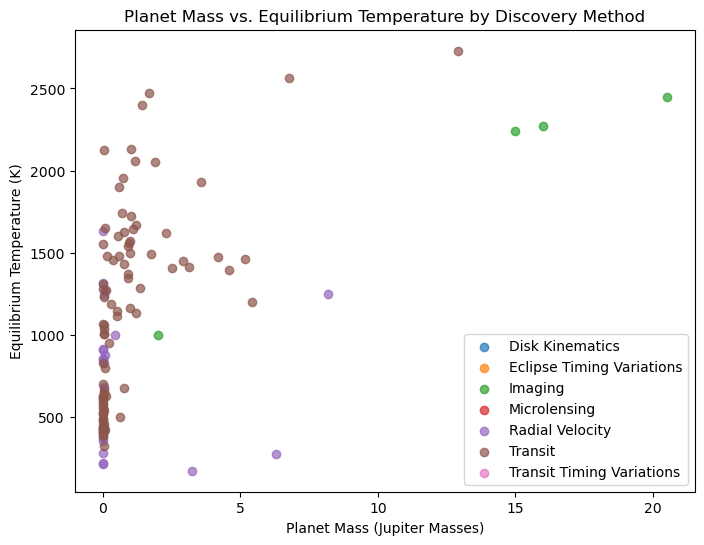

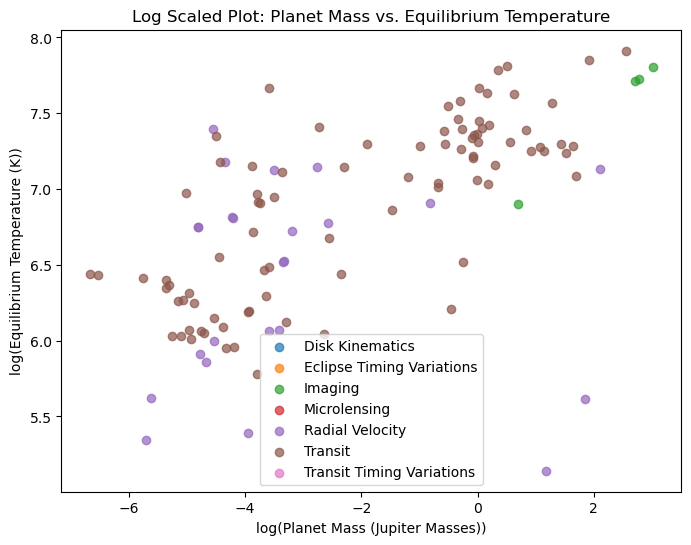

In [20]:
plt.figure(figsize=(8, 6))

for method, group in narrow.groupby("discoverymethod"):
    plt.scatter(group["pl_bmassj"], group["pl_eqt"], label=method, alpha=0.7)

plt.title("Planet Mass vs. Equilibrium Temperature by Discovery Method")
plt.xlabel("Planet Mass (Jupiter Masses)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))

for method, group in narrow.groupby("discoverymethod"):
    x = np.log(group["pl_bmassj"])
    y = np.log(group["pl_eqt"])
    plt.scatter(x, y, label=method, alpha=0.7)

plt.title("Log Scaled Plot: Planet Mass vs. Equilibrium Temperature")
plt.xlabel("log(Planet Mass (Jupiter Masses))")
plt.ylabel("log(Equilibrium Temperature (K))")
plt.legend()
plt.show()
 

In [23]:
# imaging more likeley to be quite large.
five = narrow[narrow["pl_bmassj"] > 5] 
coldest = five["pl_eqt"].idxmin()
coldest_row = five.loc[coldest]
display(coldest_row)


pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
Name: 563, dtype: object

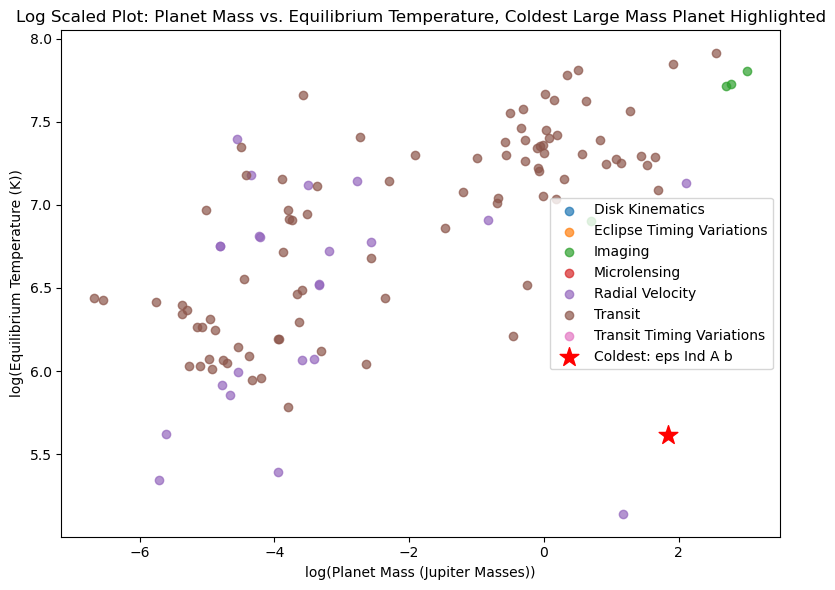

In [24]:
plt.figure(figsize=(8, 6))

for method, group in narrow.groupby("discoverymethod"):
    x = np.log(group["pl_bmassj"])
    y = np.log(group["pl_eqt"])
    plt.scatter(x, y, label=method, alpha=0.7)

cp_mass = float(coldest_row.get("pl_bmassj"))
cp_temp = float(coldest_row.get("pl_eqt"))
plt.scatter(np.log(cp_mass), np.log(cp_temp), 
            color='red', s=200, marker='*', label=f"Coldest: {coldest_row.get('pl_name')}")

plt.title("Log Scaled Plot: Planet Mass vs. Equilibrium Temperature, Coldest Large Mass Planet Highlighted")
plt.xlabel("log(Planet Mass (Jupiter Masses))")
plt.ylabel("log(Equilibrium Temperature (K))")
plt.tight_layout()
plt.legend()
plt.show()


In [25]:
print(cp_mass)
print(cp_temp)

6.31
275.0


In [ ]:
"""
Nature Paper Title: A temperate super-Jupiter imaged with JWST in the mid-infrared
- is the star we got! eps Ind A (b)
- mass: 6.31 jupiter masses, which is right.
- temp: 280 K, little different but in same ball park. 